# Project : Email Spam Detection

In [1]:
# !pip install nltk
# !pip install matplotlib
# !pip install gensim
# !pip install nltk scikit-learn
# nltk.download('all')


In [2]:
# Import Libraries

import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn import metrics
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt

print('All Library installed successfully')

All Library installed successfully


In [3]:
# Datasete loading 

data = pd.read_csv('spam.csv', encoding = 'latin-1')
data.head
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:
# drop uncessary column and rename the column

data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4' ], axis = 1, inplace = True)
data.rename(columns = {'v1': 'label', 'v2': 'text'}, inplace= True)
data

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
# EDA

# check for the missing data

data.isna().sum()

label    0
text     0
dtype: int64

In [6]:
data.shape

(5572, 2)

<Axes: xlabel='label'>

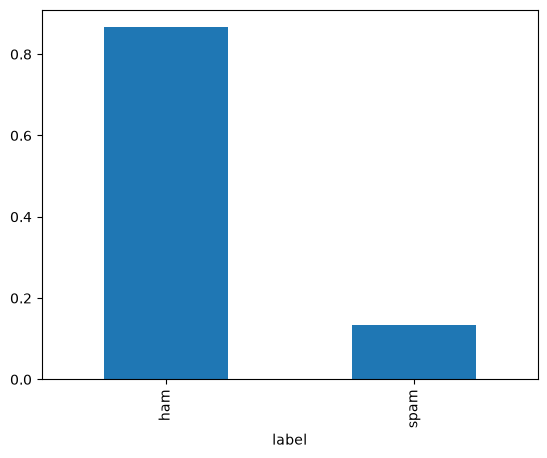

In [7]:
# check target label balance

data['label'].value_counts(normalize = True).plot.bar()

In [8]:
data['label'].value_counts(normalize = True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

In [9]:
# Text preprocessing

def preprocess_pipeline(text_data):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Process if input is a dataset / Series / list

    if not isinstance(text_data, str):

        corpus = []

        for text in text_data:
            r = re.sub('[^a-zA-Z]', ' ', text)
            r = r.lower()
            r = r.split()
            r = [word for word in r if word not in stop_words]
            r = [lemmatizer.lemmatize(word) for word in r]
            r = " ".join(r)
            corpus.append(r)
        return corpus
        
        # processed if the input is a string
    else:
        r = re.sub('[^a-zA-Z]', ' ', text_data)
        r = r.lower()
        r = r.split()
        r = [word for word in r if word not in stop_words]
        r = [lemmatizer.lemmatize(word) for word in r]
        r = " ".join(r)
        return r    

In [10]:
preprocessed_text = preprocess_pipeline(data['text'])
print(data['text'])
preprocessed_text

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: text, Length: 5572, dtype: str


['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hour',
 'mobile month u r entitled update latest colour mobile camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw'

In [11]:
# replace the original data with preprocessed data
data['text'] = preprocessed_text
data.head()

,label,text
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say early hor u c already say
4,ham,nah think go usf life around though


In [12]:
#convert the label into numerical representation

data['label'] = np.where(data['label'] == 'ham', 0, 1)

In [13]:
data.head()

,label,text
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah think go usf life around though


In [14]:
# create feature and target

x = data['text']
y = data['label']

In [15]:
# split into train and test data
x_train, x_test, y_train, y_test  = train_test_split(x, y , test_size = 0.2, random_state = 42, stratify = y)

In [16]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4457,), (1115,), (4457,), (1115,))

## Vectorization part
1. Bag of word(BOW)/ CountVectorization
2. TF-IDF Vectorization
3. Embedding


In [17]:
# 1. Bag of word(BOW)/ CountVectorization

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

x_train_cv = cv.fit_transform(x_train)
print(x_train_cv.shape)
x_test_cv = cv.transform(x_test)
print(x_test_cv.shape)


(4457, 6256)
(1115, 6256)


In [18]:
# TFIDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

x_train_tfidf = tfidf.fit_transform(x_train)
print(x_train_tfidf.shape)
x_test_tfidf = tfidf.transform(x_test)
print(x_test_tfidf.shape)


(4457, 6256)
(1115, 6256)


In [19]:
# Train word2Vec model

from gensim.models import Word2Vec

sentences = [sentence.split() for sentence in x_train]

w2v_model = Word2Vec(sentences, vector_size= 300, window = 10, min_count= 5, workers = 4)
 

In [20]:
def vectorize(sentence):

    words = sentence.split()
    words_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    
    if len(words_vecs) == 0:
        return np.zeros(300)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis= 0)

In [21]:
train_embed = np.array([vectorize(sentence) for sentence in x_train])
test_embed = np.array([vectorize(sentence) for sentence in x_test])

In [22]:
# pretrained embeddings

import gensim.downloader as api

embed_model = api.load("word2vec-google-news-300")

In [23]:
def vectorize(sentence):

    words = sentence.split()
    words_vecs = [embed_model[word] for word in words if word in embed_model]
    
    if len(words_vecs) == 0:
        return np.zeros(300)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis= 0)

In [24]:
train_embed_trained = np.array([vectorize(sentence) for sentence in x_train])
test_embed_trained  = np.array([vectorize(sentence) for sentence in x_test])

## Model training and evaluation    

In [25]:
# Model training and evaluation    

# 1. using bag of words

lr = LogisticRegression()
lr.fit(x_train_cv, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [26]:
probabilities = lr.predict_proba(x_test_cv)
print(probabilities)


[[0.99771282 0.00228718]
 [0.9643296  0.0356704 ]
 [0.99386636 0.00613364]
 ...
 [0.98932852 0.01067148]
 [0.99062629 0.00937371]
 [0.99403649 0.00596351]]


In [27]:
predictions = np.where(probabilities[:,1] > 0.5, 1, 0)
predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(1115,))

In [28]:
df = pd.DataFrame(metrics.confusion_matrix(y_test, predictions), index = ['ham', 'spam'], columns= ['ham', 'spam'])
df

,ham,spam
ham,966,0
spam,21,128


In [29]:
print("Precision Score:", precision_score(y_test, predictions))
print("Recall Score:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))


Precision Score: 1.0
Recall Score: 0.8590604026845637
F1 Score: 0.924187725631769
Accuracy: 0.9811659192825112


In [30]:
# 2. using TFIDF

lr = LogisticRegression()
lr.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [31]:
probabilities = lr.predict_proba(x_test_tfidf)
predictions = np.where(probabilities[:,1]> 0.5,1,0)
print(probabilities)


[[0.97448211 0.02551789]
 [0.90167997 0.09832003]
 [0.96202059 0.03797941]
 ...
 [0.96363323 0.03636677]
 [0.9603554  0.0396446 ]
 [0.96309713 0.03690287]]


In [32]:
df = pd.DataFrame(metrics.confusion_matrix(y_test, predictions), index = ['ham', 'spam'], columns= ['ham', 'spam'])
df

,ham,spam
ham,965,1
spam,33,116


In [33]:
print("Precision Score:", precision_score(y_test, predictions))
print("Recall Score:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

Precision Score: 0.9914529914529915
Recall Score: 0.7785234899328859
F1 Score: 0.8721804511278195
Accuracy: 0.9695067264573991


In [34]:
# 3. Embed model

lr = LogisticRegression()
lr.fit(train_embed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [35]:
probabilities = lr.predict_proba(test_embed)
predictions = np.where(probabilities[:,1]> 0.5, 1, 0)
print(probabilities)

[[0.81866667 0.18133333]
 [0.67869134 0.32130866]
 [0.93079546 0.06920454]
 ...
 [0.86849452 0.13150548]
 [0.88548104 0.11451896]
 [0.89075751 0.10924249]]


In [36]:
df = pd.DataFrame(metrics.confusion_matrix(y_test, predictions), index = ['ham', 'spam'], columns= ['ham', 'spam'])
df

,ham,spam
ham,966,0
spam,149,0


In [37]:
print("Precision Score:", precision_score(y_test, predictions))
print("Recall Score:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

Precision Score: 0.0
Recall Score: 0.0
F1 Score: 0.0
Accuracy: 0.8663677130044843


/Users/alismac/Documents/ITVEDANT/Python/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
# 4. Pretrained Word2Vec embedding model

lr = LogisticRegression()
lr.fit(train_embed_trained, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
probabilities = lr.predict_proba(test_embed_trained)
predictions = np.where(probabilities[:, 1] > 0.5, 1, 0)

In [40]:
df = pd.DataFrame(
    metrics.confusion_matrix(y_test, predictions),
    index=['ham', 'spam'],
    columns=['ham', 'spam']
)
df

,ham,spam
ham,945,21
spam,33,116


In [41]:
print("Precision Score:", precision_score(y_test, predictions))
print("Recall Score:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

Precision Score: 0.8467153284671532
Recall Score: 0.7785234899328859
F1 Score: 0.8111888111888111
Accuracy: 0.9515695067264573


### This project successfully builds an email spam detection system using NLP preprocessing and multiple feature extraction techniques. Among the tested approaches, Bag of Words with Logistic Regression performed the best based on the earlier results, giving the strongest F1 score and recall for spam detection.
### The local Word2Vec model performed poorly because the dataset is relatively small, so it could not learn meaningful word embeddings. Pretrained Word2Vec performed better than local Word2Vec, but still did not beat Bag of Words. For this dataset, traditional text vectorization methods like Bag of Words or TF-IDF are more effective.

### Future Scope
#### Further improve or extend the project by adding:
- Model comparison table for BOW, TF-IDF, Word2Vec, and pretrained Word2Vec.
- Hyperparameter tuning using GridSearchCV.
- More models like Naive Bayes, SVM, Random Forest, XGBoost.
- Better spam-focused evaluation using ROC-AUC, PR-AUC, and classification report.
- Threshold tuning to improve spam recall.
- A prediction function where the user enters a new email and gets Spam or Ham.
- Saving the final model using pickle or joblib.
- Deploying it with Streamlit or Flask.
- Using modern embeddings like BERT, DistilBERT, or sentence-transformers.
- Training on a larger and more recent email dataset.
#### Overall: The project is now ready, with Bag of Words + Logistic Regression as the best final choice.